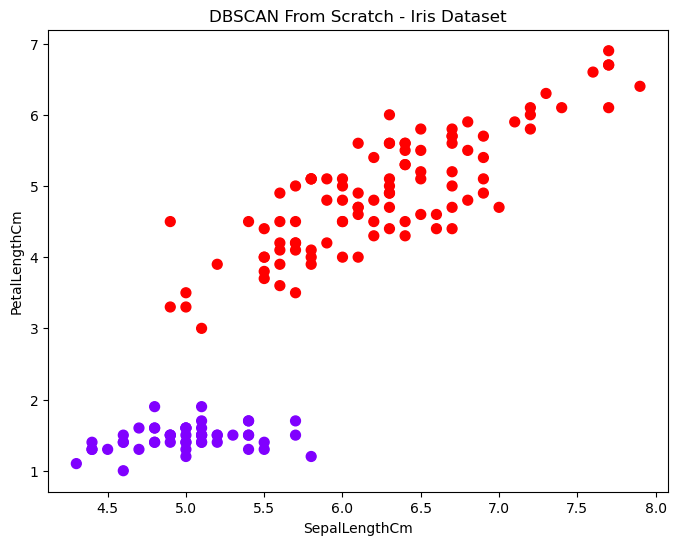

In [2]:
# DBSCAN From Scratch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# charger le dataset
df = pd.read_csv("Iris.csv")

# supprimer la colonne Id
df = df.drop("Id", axis=1)

# utiliser 2 colonnes pour la visualisation
X = df[["SepalLengthCm", "PetalLengthCm"]].values

# classe DBSCAN
class DBSCAN:

    def __init__(self, eps=0.8, min_samples=5):

        # distance maximale entre voisins
        self.eps = eps

        # nombre minimum de voisins
        self.min_samples = min_samples

    # calcul distance euclidienne
    def distance(self, p1, p2):

        return np.sqrt(np.sum((p1 - p2) ** 2))

    # trouver les voisins dans la distance 
    def get_neighbors(self, X, point_idx):

        neighbors = []

        for i in range(len(X)):

            # calcul distance entre 2 points
            dist = self.distance(X[point_idx], X[i])

            # vérifier si le point est voisin
            if dist < self.eps:

                neighbors.append(i)

        return neighbors


    # fonction principale DBSCAN
    def fit_predict(self, X):

        # nombre total des points
        n = len(X)

        # initialiser tous les points comme bruit 
        labels = [-1] * n

        # vérifier si le point est déjà visité
        visited = [False] * n

        # identifiant du cluster
        cluster_id = 0

        # parcourir tous les points
        for point_idx in range(n):

            # ignorer les points déjà visités
            if visited[point_idx]:
                continue

            # marquer comme visité
            visited[point_idx] = True

            # récupérer les voisins
            neighbors = self.get_neighbors(X, point_idx)

            # si peu de voisins donc bruit
            if len(neighbors) < self.min_samples:

                labels[point_idx] = -1

            else:

                # créer un nouveau cluster
                labels[point_idx] = cluster_id

                i = 0

                # parcourir les voisins
                while i < len(neighbors):

                    neighbor_idx = neighbors[i]

                    # vérifier si le voisin est déjà visité
                    if not visited[neighbor_idx]:

                        visited[neighbor_idx] = True

                        # récupérer ses voisins
                        new_neighbors = self.get_neighbors(X, neighbor_idx)

                        # agrandir le cluster
                        if len(new_neighbors) >= self.min_samples:

                            neighbors += new_neighbors

                    # ajouter le voisin au cluster
                    if labels[neighbor_idx] == -1:

                        labels[neighbor_idx] = cluster_id

                    i += 1

                # passer au cluster suivant
                cluster_id += 1

        return np.array(labels)

# créer le modèle
model = DBSCAN(
    eps=0.8,
    min_samples=5
)

# appliquer DBSCAN
clusters = model.fit_predict(X)

# ajouter les clusters au dataframe
df["Cluster"] = clusters

# visualisation

plt.figure(figsize=(8,6))

plt.scatter(
    df["SepalLengthCm"],
    df["PetalLengthCm"],
    c=clusters,
    cmap="rainbow",
    s=50
)

plt.xlabel("SepalLengthCm")
plt.ylabel("PetalLengthCm")


plt.show()